# ACLED Africa: spatiotemporal grid model for conflict clustering

**Research question:** Do conflict clusters spread over time?

This notebook builds a first reproducible model that transforms ACLED events in Africa, 2000-2010, into a **grid-cell x month** panel. The main specification uses a **100 x 100 km grid**, with robustness checks at **50, 100, and 200 km**.

Analytical idea: if previous conflict in neighboring cells improves prediction of conflict next month, even after controlling for conflict history in the same cell, this provides evidence of spatiotemporal clustering or diffusion.

Temporal split:
- 2000-2005: training / model development
- 2006-2010: validation within the first dataset
- 2011-2020: reserved for a later final out-of-sample test

Project layout:
- `data/`: source CSV copied into the project folder
- `notebooks/`: this research notebook
- `outputs/tables/`: model summaries and evaluation tables
- `outputs/figures/`: saved charts also displayed inline by the notebook
- `outputs/panels/`: generated cell-month panels and validation predictions
- `docs/`: README and project notes

## 0. Installation

Run the cell below only if your VSCode kernel is missing the required packages.

In [1]:
# Run if needed in VSCode:
# %pip install pandas numpy matplotlib scikit-learn seaborn nbformat

In [2]:
from pathlib import Path
import math
import os
import sys
import subprocess
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

try:
    from IPython.display import display, Image
except Exception:
    Image = None
    def display(x):
        print(x)
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, precision_recall_fscore_support, precision_recall_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.calibration import calibration_curve

REPO_URL = "https://github.com/Mat99999/acled-spatiotemporal-conflict-model.git"  # Used by Colab to clone the full project when needed.
PROJECT_FOLDER_NAME = "acled_spatiotemporal_project"
DATA_FILENAME = "ACLED Data_2026-06-17.csv"

def running_in_colab():
    return "google.colab" in sys.modules

def find_project_dir():
    """Find the project root without hard-coded local paths."""
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent, cwd / PROJECT_FOLDER_NAME, cwd.parent / PROJECT_FOLDER_NAME]
    for candidate in candidates:
        if (candidate / "data" / DATA_FILENAME).exists() and (candidate / "outputs").exists():
            return candidate

    # If opened directly in Colab from GitHub, the files are not automatically cloned.
    # Once REPO_URL is filled, this makes the notebook self-bootstrapping in Colab.
    if running_in_colab() and REPO_URL:
        clone_dir = Path("/content") / PROJECT_FOLDER_NAME
        if not clone_dir.exists():
            subprocess.run(["git", "clone", REPO_URL, str(clone_dir)], check=True)
        return clone_dir

    raise FileNotFoundError(
        "Could not locate the project folder. Run this notebook from the cloned "
        f"{PROJECT_FOLDER_NAME} repository root, or keep the notebook inside the "
        "project's notebooks/ folder. Expected data file: data/" + DATA_FILENAME
    )

PROJECT_DIR = find_project_dir()
DATA_PATH = PROJECT_DIR / "data" / DATA_FILENAME
OUTPUT_DIR = PROJECT_DIR / "outputs"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"
PANELS_DIR = OUTPUT_DIR / "panels"
for directory in [TABLES_DIR, FIGURES_DIR, PANELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

def save_and_show(fig, filename, dpi=140):
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=dpi)
    if Image is not None:
        display(Image(filename=str(path)))
    else:
        print(f"Saved figure: {path}")
    plt.close(fig)

RANDOM_STATE = 42
PRIMARY_GRID_KM = 100
ROBUSTNESS_GRID_KM = [50, 100, 200]
TRAIN_END = pd.Timestamp('2005-12-31')
VALID_START = pd.Timestamp('2006-01-01')
VALID_END = pd.Timestamp('2010-12-31')

print('Data:', DATA_PATH)
print('Project:', PROJECT_DIR)
print('Output:', OUTPUT_DIR)

Data: /content/acled_spatiotemporal_project/data/ACLED Data_2026-06-17.csv
Project: /content/acled_spatiotemporal_project
Output: /content/acled_spatiotemporal_project/outputs


## 1. Load and validate ACLED

ACLED is event-level data. Each row is a reported event; the prediction panel is created below.

In [3]:
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip().lower() for c in df.columns]

df['event_date'] = pd.to_datetime(df['event_date'], errors='coerce')
df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')
df['fatalities'] = pd.to_numeric(df['fatalities'], errors='coerce').fillna(0)
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
df['month'] = df['event_date'].dt.to_period('M').dt.to_timestamp()

required = ['event_date','month','latitude','longitude','country','event_type','sub_event_type','fatalities']
print('Rows:', len(df))
print('Date range:', df['event_date'].min(), 'to', df['event_date'].max())
display(df[required].isna().sum().to_frame('missing'))
display(df.head(3))

Rows: 41299
Date range: 2000-01-01 00:00:00 to 2010-12-31 00:00:00


,missing
event_date,0
month,0
latitude,0
longitude,0
country,0
event_type,0
sub_event_type,0
fatalities,0


,event_id_cnty,event_date,year,time_precision,disorder_type,event_type,sub_event_type,actor1,assoc_actor_1,inter1,...,latitude,longitude,geo_precision,source,source_scale,notes,fatalities,tags,timestamp,month
0,EGY73,2000-01-01,2000,1,Political violence,Battles,Armed clash,Muslim Militia (Egypt),NaN,Identity militia,...,26.5500,31.7000,1,Reuters,International,At least three men were wounded in the souther...,0,NaN,1618529299,2000-01-01
1,SOM139,2000-01-01,2000,1,Political violence,Violence against civilians,Attack,Unidentified Armed Group (Somalia),NaN,Political militia,...,8.4774,47.3597,1,BBC News,International,"Midnimo website. Unknown attackers, Somaliland...",0,NaN,1572403704,2000-01-01
2,NIG519,2000-01-01,2000,1,Political violence,Violence against civilians,Attack,Unidentified Armed Group (Nigeria),NaN,Political militia,...,6.4531,3.3958,1,Xinhua,International,Five were killed in Lagos during New Years cel...,5,NaN,1572403786,2000-01-01


,metric,value
0,events,41299.000
1,countries,48.000
2,months,132.000
3,fatalities_total,186188.000
4,share_zero_fatalities,0.634


,event_type,events
0,Battles,15298
1,Violence against civilians,13721
2,Protests,4137
3,Riots,3147
4,Explosions/Remote violence,2649
5,Strategic developments,2347


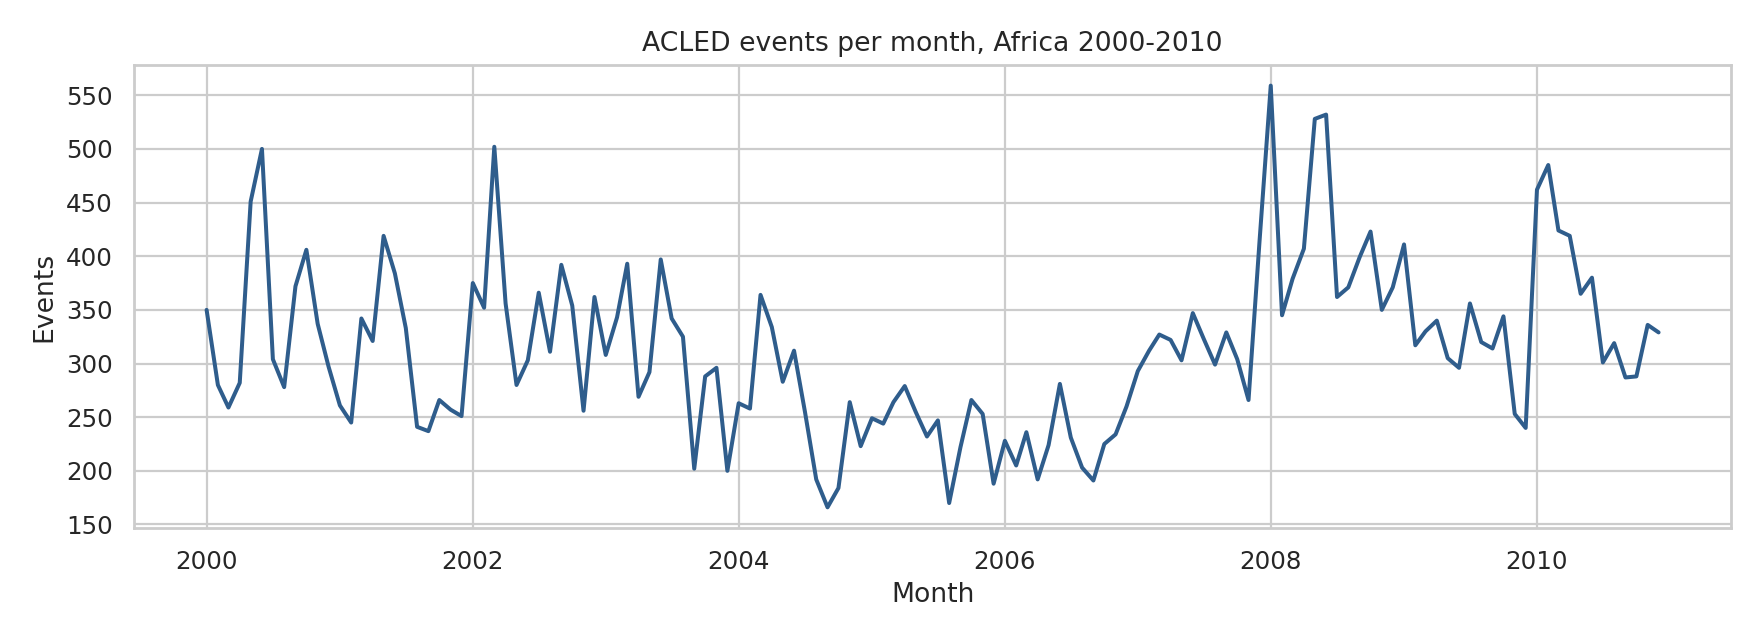

In [4]:
summary = pd.DataFrame({
    'metric': ['events','countries','months','fatalities_total','share_zero_fatalities'],
    'value': [len(df), df['country'].nunique(), df['month'].nunique(), int(df['fatalities'].sum()), round((df['fatalities']==0).mean(), 3)]
})
by_type = df['event_type'].value_counts().rename_axis('event_type').reset_index(name='events')
display(summary)
display(by_type)
summary.to_csv(TABLES_DIR / '01_data_summary.csv', index=False)
by_type.to_csv(TABLES_DIR / '02_event_types.csv', index=False)

monthly = df.groupby('month').size().rename('events').reset_index()
fig, ax = plt.subplots(figsize=(11,4))
ax.plot(monthly['month'], monthly['events'], color='#2F5D8C', linewidth=1.8)
ax.set_title('ACLED events per month, Africa 2000-2010')
ax.set_xlabel('Month')
ax.set_ylabel('Events')
fig.tight_layout()
save_and_show(fig, 'events_per_month.png', dpi=160)

## 2. Grid: approximate kilometer cells

This first version uses a simple kilometer approximation to avoid heavy GIS setup. It is useful for model development, but a later publication-grade version should use an equal-area projection, for example with GeoPandas.

In [5]:
def add_grid_columns(events: pd.DataFrame, grid_km: int) -> pd.DataFrame:
    out = events.copy()
    lat0 = out['latitude'].median()
    km_per_degree_lat = 111.0
    km_per_degree_lon = 111.0 * math.cos(math.radians(lat0))
    out['x_km'] = out['longitude'] * km_per_degree_lon
    out['y_km'] = out['latitude'] * km_per_degree_lat
    out['grid_x'] = np.floor(out['x_km'] / grid_km).astype(int)
    out['grid_y'] = np.floor(out['y_km'] / grid_km).astype(int)
    out['cell_id'] = out['grid_x'].astype(str) + '_' + out['grid_y'].astype(str)
    out['grid_km'] = grid_km
    return out

df_grid = add_grid_columns(df.dropna(subset=['latitude','longitude','month']), PRIMARY_GRID_KM)
print('Grid cells with at least one event:', df_grid['cell_id'].nunique())
display(df_grid[['event_date','country','event_type','fatalities','latitude','longitude','grid_x','grid_y','cell_id']].head())

Grid cells with at least one event: 1432


,event_date,country,event_type,fatalities,latitude,longitude,grid_x,grid_y,cell_id
0,2000-01-01,Egypt,Battles,0,26.5500,31.7000,35,29,35_29
1,2000-01-01,Somalia,Violence against civilians,0,8.4774,47.3597,52,9,52_9
2,2000-01-01,Nigeria,Violence against civilians,5,6.4531,3.3958,3,7,3_7
3,2000-01-01,Republic of Congo,Battles,80,3.5300,18.4000,20,3,20_3
4,2000-01-01,Somalia,Violence against civilians,2,2.0414,45.3337,50,2,50_2


## 3. Build the cell-month panel and features

The panel includes cells that had at least one reported event during 2000-2010. This is a deliberate first-stage restriction to avoid oceans, unpopulated areas, and a very large number of irrelevant zero observations.

In [6]:
def build_panel(events: pd.DataFrame, grid_km: int, include_event_types=True) -> pd.DataFrame:
    e = add_grid_columns(events.dropna(subset=['latitude','longitude','month']), grid_km)
    e = e[(e['event_date'] >= '2000-01-01') & (e['event_date'] <= '2010-12-31')].copy()

    agg = e.groupby(['cell_id','grid_x','grid_y','month']).agg(
        events=('event_id_cnty','count'),
        fatalities=('fatalities','sum'),
        modal_country=('country', lambda s: s.mode().iat[0] if not s.mode().empty else np.nan)
    ).reset_index()

    if include_event_types:
        type_counts = e.pivot_table(index=['cell_id','month'], columns='event_type', values='event_id_cnty', aggfunc='count', fill_value=0).reset_index()
        type_counts.columns = ['cell_id','month'] + [f"type_{str(c).lower().replace(' ', '_').replace('/', '_')}" for c in type_counts.columns[2:]]
        agg = agg.merge(type_counts, on=['cell_id','month'], how='left')

    cells = agg[['cell_id','grid_x','grid_y']].drop_duplicates()
    months = pd.date_range(e['month'].min(), e['month'].max(), freq='MS')
    panel = cells.merge(pd.DataFrame({'month': months}), how='cross')
    panel = panel.merge(agg, on=['cell_id','grid_x','grid_y','month'], how='left')

    count_cols = ['events','fatalities'] + [c for c in panel.columns if c.startswith('type_')]
    panel[count_cols] = panel[count_cols].fillna(0)
    panel['modal_country'] = panel.groupby('cell_id')['modal_country'].ffill().bfill()
    panel['conflict'] = (panel['events'] > 0).astype(int)
    panel = panel.sort_values(['cell_id','month']).reset_index(drop=True)

    for lag in [1,2,3,6,12]:
        panel[f'events_lag_{lag}'] = panel.groupby('cell_id')['events'].shift(lag).fillna(0)
        panel[f'fatalities_lag_{lag}'] = panel.groupby('cell_id')['fatalities'].shift(lag).fillna(0)
        panel[f'conflict_lag_{lag}'] = panel.groupby('cell_id')['conflict'].shift(lag).fillna(0)

    panel['events_roll_3'] = panel.groupby('cell_id')['events'].transform(lambda s: s.shift(1).rolling(3, min_periods=1).sum()).fillna(0)
    panel['events_roll_6'] = panel.groupby('cell_id')['events'].transform(lambda s: s.shift(1).rolling(6, min_periods=1).sum()).fillna(0)
    panel['fatalities_roll_3'] = panel.groupby('cell_id')['fatalities'].transform(lambda s: s.shift(1).rolling(3, min_periods=1).sum()).fillna(0)

    base = panel[['grid_x','grid_y','month','events','fatalities','conflict']].copy()
    shifted_neighbors = []
    for dx in [-1,0,1]:
        for dy in [-1,0,1]:
            if dx == 0 and dy == 0:
                continue
            tmp = base.copy()
            tmp['grid_x'] = tmp['grid_x'] - dx
            tmp['grid_y'] = tmp['grid_y'] - dy
            shifted_neighbors.append(tmp)
    neigh = pd.concat(shifted_neighbors, ignore_index=True)
    neigh_agg = neigh.groupby(['grid_x','grid_y','month']).agg(
        neighbor_events=('events','sum'),
        neighbor_fatalities=('fatalities','sum'),
        neighbor_conflict_cells=('conflict','sum')
    ).reset_index()
    neigh_agg['month'] = neigh_agg['month'] + pd.offsets.MonthBegin(1)
    panel = panel.merge(neigh_agg, on=['grid_x','grid_y','month'], how='left')
    for c in ['neighbor_events','neighbor_fatalities','neighbor_conflict_cells']:
        panel[c] = panel[c].fillna(0)

    panel['target_conflict_next_month'] = panel.groupby('cell_id')['conflict'].shift(-1)
    panel['target_events_next_month'] = panel.groupby('cell_id')['events'].shift(-1)
    panel['month_num'] = panel['month'].dt.month
    panel['year'] = panel['month'].dt.year
    panel['sin_month'] = np.sin(2*np.pi*panel['month_num']/12)
    panel['cos_month'] = np.cos(2*np.pi*panel['month_num']/12)
    return panel.dropna(subset=['target_conflict_next_month']).reset_index(drop=True)

panel100 = build_panel(df, PRIMARY_GRID_KM)
print(panel100.shape)
print('Cells:', panel100['cell_id'].nunique(), '| positive target share:', round(panel100['target_conflict_next_month'].mean(), 4))
display(panel100.head())
panel100.to_csv(PANELS_DIR / 'panel_100km_month.csv', index=False)

(187592, 41)
Cells: 1432 | positive target share: 0.0805


,cell_id,grid_x,grid_y,month,events,fatalities,modal_country,type_battles,type_explosions_remote_violence,type_protests,...,fatalities_roll_3,neighbor_events,neighbor_fatalities,neighbor_conflict_cells,target_conflict_next_month,target_events_next_month,month_num,year,sin_month,cos_month
0,-10_10,-10,10,2000-01-01,0.0,0.0,Guinea,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,2000,0.500000,8.660254e-01
1,-10_10,-10,10,2000-02-01,0.0,0.0,Guinea,0.0,0.0,0.0,...,0.0,5.0,31.0,1.0,0.0,0.0,2,2000,0.866025,5.000000e-01
2,-10_10,-10,10,2000-03-01,0.0,0.0,Guinea,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3,2000,1.000000,6.123234e-17
3,-10_10,-10,10,2000-04-01,0.0,0.0,Guinea,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,4,2000,0.866025,-5.000000e-01
4,-10_10,-10,10,2000-05-01,0.0,0.0,Guinea,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,5,2000,0.500000,-8.660254e-01


,metric,value
0,grid_km,100.0000
1,cell_months,187592.0000
2,cells,1432.0000
3,months,131.0000
4,positive_target_share,0.0805
5,mean_events_when_positive,2.7100


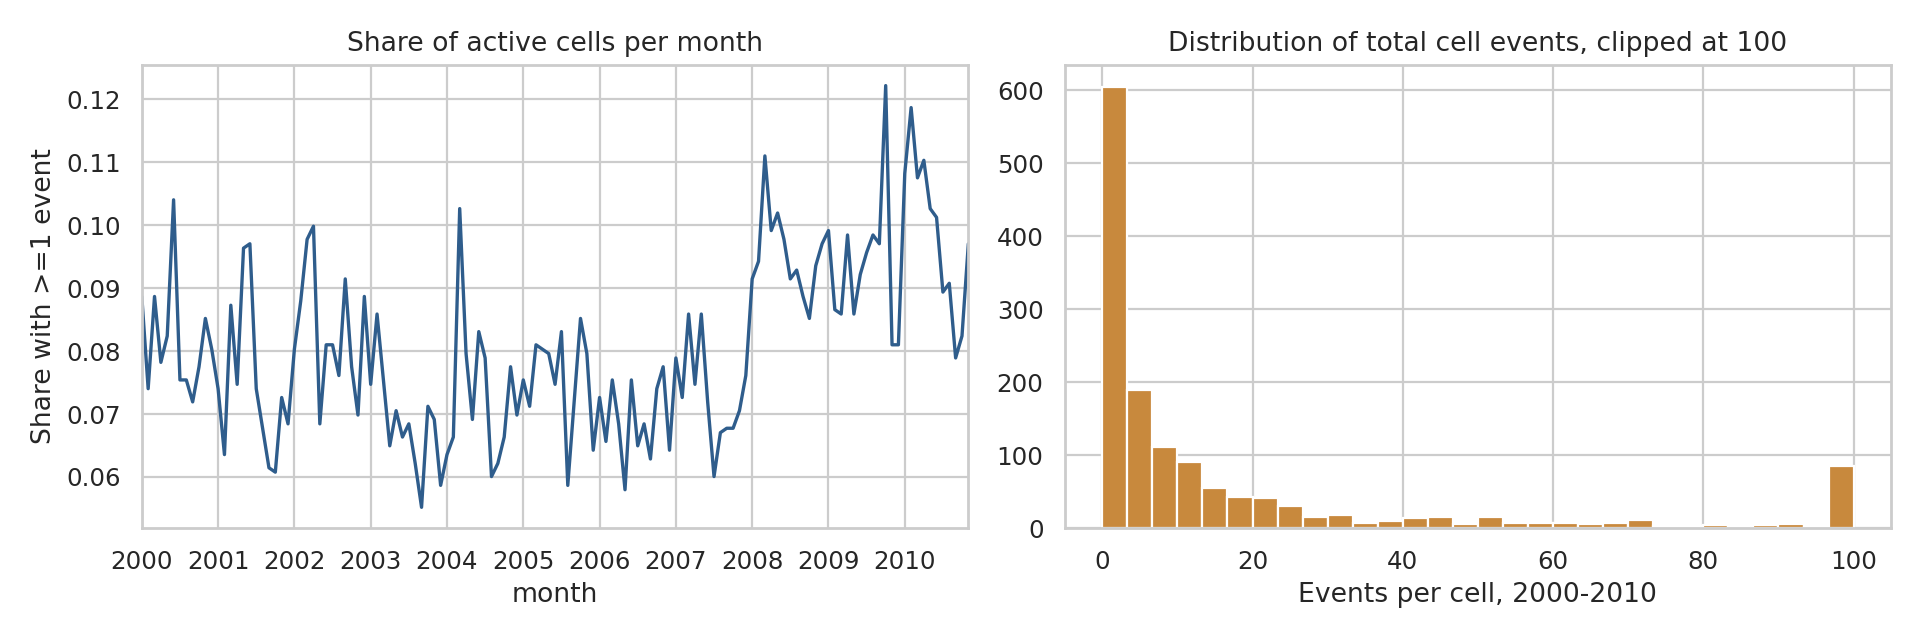

In [7]:
panel_summary = pd.DataFrame({
    'metric': ['grid_km','cell_months','cells','months','positive_target_share','mean_events_when_positive'],
    'value': [PRIMARY_GRID_KM, len(panel100), panel100['cell_id'].nunique(), panel100['month'].nunique(), round(panel100['target_conflict_next_month'].mean(), 4), round(panel100.loc[panel100['events']>0, 'events'].mean(), 2)]
})
display(panel_summary)
panel_summary.to_csv(TABLES_DIR / '03_panel_100km_summary.csv', index=False)

fig, axes = plt.subplots(1,2,figsize=(12,4))
panel100.groupby('month')['conflict'].mean().plot(ax=axes[0], color='#2F5D8C')
axes[0].set_title('Share of active cells per month')
axes[0].set_ylabel('Share with >=1 event')
panel100.groupby('cell_id')['events'].sum().clip(upper=100).hist(ax=axes[1], bins=30, color='#C8893D')
axes[1].set_title('Distribution of total cell events, clipped at 100')
axes[1].set_xlabel('Events per cell, 2000-2010')
fig.tight_layout()
save_and_show(fig, 'panel_diagnostics_100km.png', dpi=160)

## 4. Modeling strategy

We compare four feature sets:

- **A_place_time:** location and time
- **B_local_history:** location/time plus previous conflict in the same cell
- **C_local_plus_neighbors:** local history plus conflict in the eight neighboring cells in the previous month
- **D_extended:** C plus fatalities and event-type variables

The main test is whether C improves on B.

In [8]:
BASE_FEATURES = ['grid_x','grid_y','year','sin_month','cos_month']
LOCAL_FEATURES = BASE_FEATURES + ['events_lag_1','events_lag_2','events_lag_3','events_lag_6','events_lag_12','conflict_lag_1','conflict_lag_3','conflict_lag_6','events_roll_3','events_roll_6']
SPATIAL_FEATURES = LOCAL_FEATURES + ['neighbor_events','neighbor_fatalities','neighbor_conflict_cells']
TYPE_FEATURES = [c for c in panel100.columns if c.startswith('type_')]
EXTENDED_FEATURES = SPATIAL_FEATURES + ['fatalities_lag_1','fatalities_lag_3','fatalities_lag_6','fatalities_roll_3'] + TYPE_FEATURES
FEATURE_SETS = {'A_place_time': BASE_FEATURES, 'B_local_history': LOCAL_FEATURES, 'C_local_plus_neighbors': SPATIAL_FEATURES, 'D_extended': EXTENDED_FEATURES}

def make_masks(panel):
    train = panel['month'] <= TRAIN_END
    valid = (panel['month'] >= VALID_START) & (panel['month'] <= VALID_END)
    return train, valid

train_mask, valid_mask = make_masks(panel100)
print('Train rows:', train_mask.sum(), 'Validation rows:', valid_mask.sum())
print('Train positive share:', round(panel100.loc[train_mask, 'target_conflict_next_month'].mean(), 4))
print('Validation positive share:', round(panel100.loc[valid_mask, 'target_conflict_next_month'].mean(), 4))

Train rows: 103104 Validation rows: 84488
Train positive share: 0.076
Validation positive share: 0.086


In [9]:
def evaluate_predictions(y_true, y_prob, threshold=None):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)
    if threshold is None:
        threshold = y_true.mean()
    y_pred = (y_prob >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    return {
        'roc_auc': roc_auc_score(y_true, y_prob),
        'avg_precision': average_precision_score(y_true, y_prob),
        'brier': brier_score_loss(y_true, y_prob),
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'positive_rate_pred': y_pred.mean(),
    }

def fit_models(panel, feature_sets):
    train_mask, valid_mask = make_masks(panel)
    y_train = panel.loc[train_mask, 'target_conflict_next_month'].astype(int)
    y_valid = panel.loc[valid_mask, 'target_conflict_next_month'].astype(int)
    predictions = panel.loc[valid_mask, ['cell_id','grid_x','grid_y','month','target_conflict_next_month','events','neighbor_events']].copy()
    results = []

    for name, features in feature_sets.items():
        features = [f for f in features if f in panel.columns]
        X_train = panel.loc[train_mask, features].fillna(0)
        X_valid = panel.loc[valid_mask, features].fillna(0)

        logit = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
        logit.fit(X_train, y_train)
        p_logit = logit.predict_proba(X_valid)[:,1]
        row = {'model': f'Logit_{name}', 'feature_set': name, 'n_features': len(features)}
        row.update(evaluate_predictions(y_valid, p_logit))
        results.append(row)
        predictions[f'p_Logit_{name}'] = p_logit

        rf = RandomForestClassifier(n_estimators=100, min_samples_leaf=10, class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE)
        rf.fit(X_train, y_train)
        p_rf = rf.predict_proba(X_valid)[:,1]
        row = {'model': f'RF_{name}', 'feature_set': name, 'n_features': len(features)}
        row.update(evaluate_predictions(y_valid, p_rf))
        results.append(row)
        predictions[f'p_RF_{name}'] = p_rf

    return pd.DataFrame(results).sort_values(['avg_precision','roc_auc'], ascending=False), predictions

results100, pred100 = fit_models(panel100, FEATURE_SETS)
display(results100)
results100.to_csv(TABLES_DIR / '04_model_results_100km.csv', index=False)
pred100.to_csv(PANELS_DIR / 'predictions_100km_validation.csv', index=False)

,model,feature_set,n_features,roc_auc,avg_precision,brier,threshold,precision,recall,f1,positive_rate_pred
7,RF_D_extended,D_extended,28,0.844162,0.499253,0.111483,0.086,0.087829,0.998761,0.161460,0.977961
6,Logit_D_extended,D_extended,28,0.836736,0.497851,0.130608,0.086,0.086000,1.000000,0.158380,1.000000
5,RF_C_local_plus_neighbors,C_local_plus_neighbors,18,0.829764,0.476184,0.103440,0.086,0.110195,0.945087,0.197376,0.737584
3,RF_B_local_history,B_local_history,15,0.826246,0.473382,0.108090,0.086,0.112819,0.935453,0.201354,0.713084
4,Logit_C_local_plus_neighbors,C_local_plus_neighbors,18,0.825059,0.470489,0.132528,0.086,0.086000,1.000000,0.158380,1.000000
2,Logit_B_local_history,B_local_history,15,0.810478,0.465898,0.133163,0.086,0.086000,1.000000,0.158380,1.000000
1,RF_A_place_time,A_place_time,5,0.775804,0.305712,0.117313,0.086,0.106642,0.930773,0.191359,0.750615
0,Logit_A_place_time,A_place_time,5,0.536445,0.096507,0.227345,0.086,0.086000,1.000000,0.158380,1.000000


## 5. Main interpretation: do neighboring cells add predictive information?

,model_family,feature_set,avg_precision,brier,f1,roc_auc
0,Logit,A_place_time,0.096507,0.227345,0.158380,0.536445
1,Logit,B_local_history,0.465898,0.133163,0.158380,0.810478
2,Logit,C_local_plus_neighbors,0.470489,0.132528,0.158380,0.825059
3,Logit,D_extended,0.497851,0.130608,0.158380,0.836736
4,RF,A_place_time,0.305712,0.117313,0.191359,0.775804
5,RF,B_local_history,0.473382,0.108090,0.201354,0.826246
6,RF,C_local_plus_neighbors,0.476184,0.103440,0.197376,0.829764
7,RF,D_extended,0.499253,0.111483,0.161460,0.844162


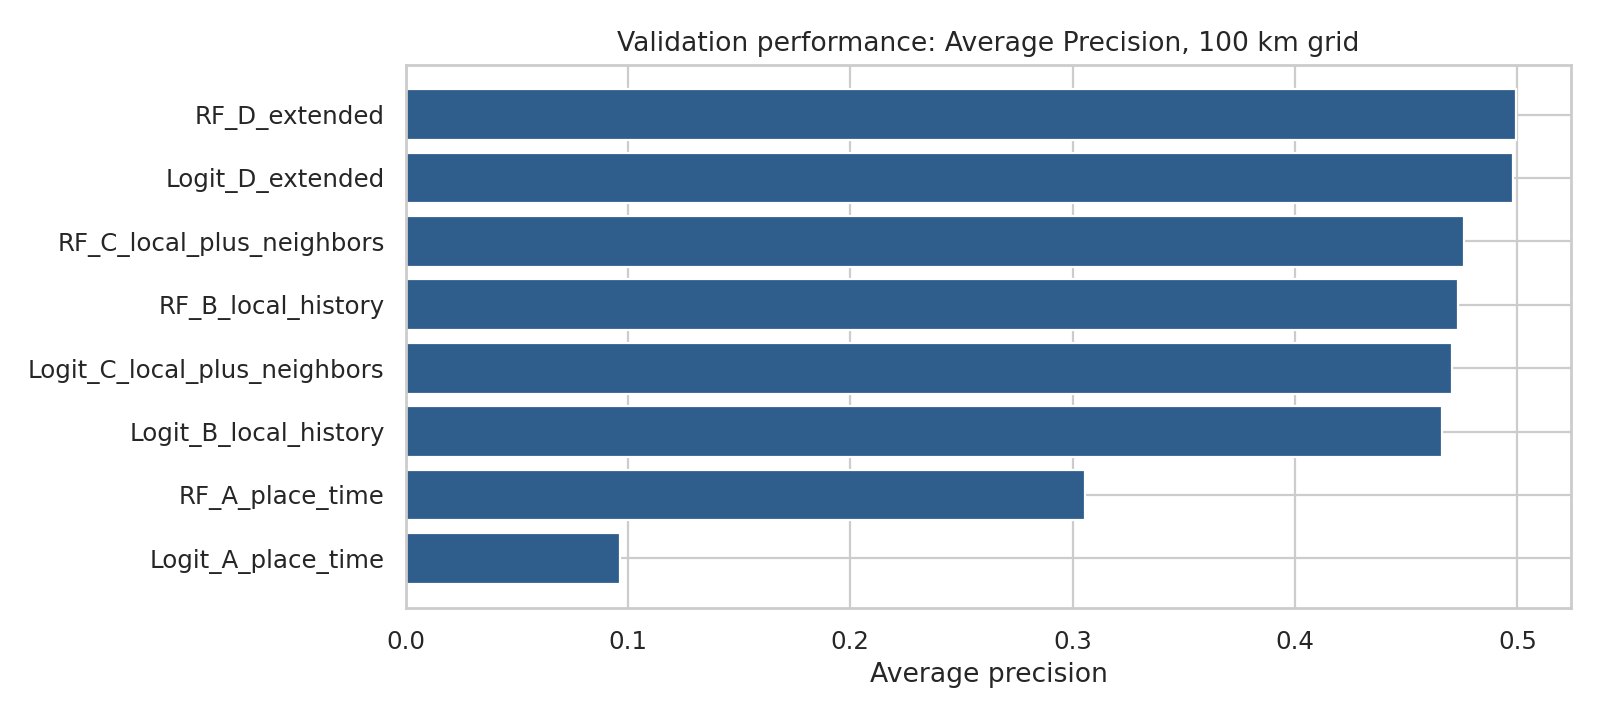

In [10]:
comparison = results100.copy()
comparison['model_family'] = comparison['model'].str.extract(r'^(Logit|RF)_')
pivot = comparison.pivot_table(index=['model_family','feature_set'], values=['roc_auc','avg_precision','brier','f1'], aggfunc='first').reset_index()
display(pivot)
pivot.to_csv(TABLES_DIR / '05_feature_set_comparison_100km.csv', index=False)

fig, ax = plt.subplots(figsize=(10,4.5))
plot_df = results100.sort_values('avg_precision', ascending=True)
ax.barh(plot_df['model'], plot_df['avg_precision'], color='#2F5D8C')
ax.set_title('Validation performance: Average Precision, 100 km grid')
ax.set_xlabel('Average precision')
ax.set_ylabel('')
fig.tight_layout()
save_and_show(fig, 'model_average_precision_100km.png', dpi=160)

## 6. Threshold, ranking, and calibration diagnostics

F1 is highly sensitive to the classification threshold. In rare-event prediction, the model can have useful ranking ability even when a default threshold gives weak F1. This section adds more appropriate diagnostics:

- **Precision@top 1%, 5%, and 10%** of highest-risk cell-months
- **PR curves** for model ranking under class imbalance
- **Calibration curves** to compare predicted risk with observed conflict rates
- **F1-optimal threshold**, separated from the base-rate threshold used above
- **Neighbor uplift table**, comparing B versus C directly

In [11]:
def threshold_sweep(y_true, y_prob, n_grid=501):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)
    thresholds = np.linspace(0, 1, n_grid)
    rows = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
        rows.append({'threshold': t, 'precision': precision, 'recall': recall, 'f1': f1, 'positive_rate_pred': y_pred.mean()})
    return pd.DataFrame(rows)

def precision_at_top_k(y_true, y_prob, top_shares=(0.01, 0.05, 0.10)):
    d = pd.DataFrame({'y_true': np.asarray(y_true).astype(int), 'y_prob': np.asarray(y_prob)})
    d = d.sort_values('y_prob', ascending=False).reset_index(drop=True)
    rows = []
    n = len(d)
    for share in top_shares:
        k = max(1, int(np.ceil(n * share)))
        top = d.iloc[:k]
        rows.append({
            'top_share': share,
            'n_flagged': k,
            'precision_at_top': top['y_true'].mean(),
            'recall_at_top': top['y_true'].sum() / d['y_true'].sum(),
            'lift_vs_base_rate': top['y_true'].mean() / d['y_true'].mean(),
        })
    return pd.DataFrame(rows)

# Choose interpretable comparison models.
y_valid = pred100['target_conflict_next_month'].astype(int)
model_cols = {
    'RF_B_local_history': 'p_RF_B_local_history',
    'RF_C_local_plus_neighbors': 'p_RF_C_local_plus_neighbors',
    'RF_D_extended': 'p_RF_D_extended',
    'Logit_C_local_plus_neighbors': 'p_Logit_C_local_plus_neighbors',
}
model_cols = {k: v for k, v in model_cols.items() if v in pred100.columns}

threshold_rows = []
topk_rows = []
for model_name, col in model_cols.items():
    probs = pred100[col]
    sweep = threshold_sweep(y_valid, probs)
    best = sweep.loc[sweep['f1'].idxmax()].copy()
    best['model'] = model_name
    best['base_rate'] = y_valid.mean()
    threshold_rows.append(best)

    topk = precision_at_top_k(y_valid, probs)
    topk.insert(0, 'model', model_name)
    topk_rows.append(topk)

threshold_eval = pd.DataFrame(threshold_rows)[['model','base_rate','threshold','precision','recall','f1','positive_rate_pred']]
topk_eval = pd.concat(topk_rows, ignore_index=True)

display(threshold_eval)
display(topk_eval)
threshold_eval.to_csv(TABLES_DIR / '08_f1_optimal_thresholds_100km.csv', index=False)
topk_eval.to_csv(TABLES_DIR / '09_precision_at_top_k_100km.csv', index=False)

# Neighbor uplift: C minus B for the same model family.
uplift_rows = []
for family in ['RF', 'Logit']:
    b = results100[(results100['model'] == f'{family}_B_local_history')].iloc[0]
    c = results100[(results100['model'] == f'{family}_C_local_plus_neighbors')].iloc[0]
    uplift_rows.append({
        'model_family': family,
        'roc_auc_B': b['roc_auc'],
        'roc_auc_C': c['roc_auc'],
        'delta_roc_auc_C_minus_B': c['roc_auc'] - b['roc_auc'],
        'avg_precision_B': b['avg_precision'],
        'avg_precision_C': c['avg_precision'],
        'delta_avg_precision_C_minus_B': c['avg_precision'] - b['avg_precision'],
        'brier_B': b['brier'],
        'brier_C': c['brier'],
        'delta_brier_C_minus_B': c['brier'] - b['brier'],
    })
neighbor_uplift = pd.DataFrame(uplift_rows)
display(neighbor_uplift)
neighbor_uplift.to_csv(TABLES_DIR / '10_neighbor_uplift_B_vs_C_100km.csv', index=False)


,model,base_rate,threshold,precision,recall,f1,positive_rate_pred
340,RF_B_local_history,0.086,0.680,0.474332,0.471786,0.473056,0.085539
322,RF_C_local_plus_neighbors,0.086,0.644,0.470261,0.476603,0.473411,0.087160
328,RF_D_extended,0.086,0.656,0.480852,0.494220,0.487444,0.088391
344,Logit_C_local_plus_neighbors,0.086,0.688,0.467565,0.482108,0.474726,0.088675


,model,top_share,n_flagged,precision_at_top,recall_at_top,lift_vs_base_rate
0,RF_B_local_history,0.01,845,0.873373,0.101569,10.155453
1,RF_B_local_history,0.05,4225,0.600473,0.349160,6.982218
2,RF_B_local_history,0.10,8449,0.436501,0.507570,5.075575
3,RF_C_local_plus_neighbors,0.01,845,0.871006,0.101294,10.127931
4,RF_C_local_plus_neighbors,0.05,4225,0.597870,0.347647,6.951944
5,RF_C_local_plus_neighbors,0.10,8449,0.440407,0.512111,5.120991
6,RF_D_extended,0.01,845,0.894675,0.104046,10.403147
7,RF_D_extended,0.05,4225,0.615148,0.357693,7.152851
8,RF_D_extended,0.10,8449,0.450941,0.524360,5.243476
9,Logit_C_local_plus_neighbors,0.01,845,0.847337,0.098541,9.852716


,model_family,roc_auc_B,roc_auc_C,delta_roc_auc_C_minus_B,avg_precision_B,avg_precision_C,delta_avg_precision_C_minus_B,brier_B,brier_C,delta_brier_C_minus_B
0,RF,0.826246,0.829764,0.003518,0.473382,0.476184,0.002803,0.108090,0.103440,-0.004650
1,Logit,0.810478,0.825059,0.014581,0.465898,0.470489,0.004590,0.133163,0.132528,-0.000636


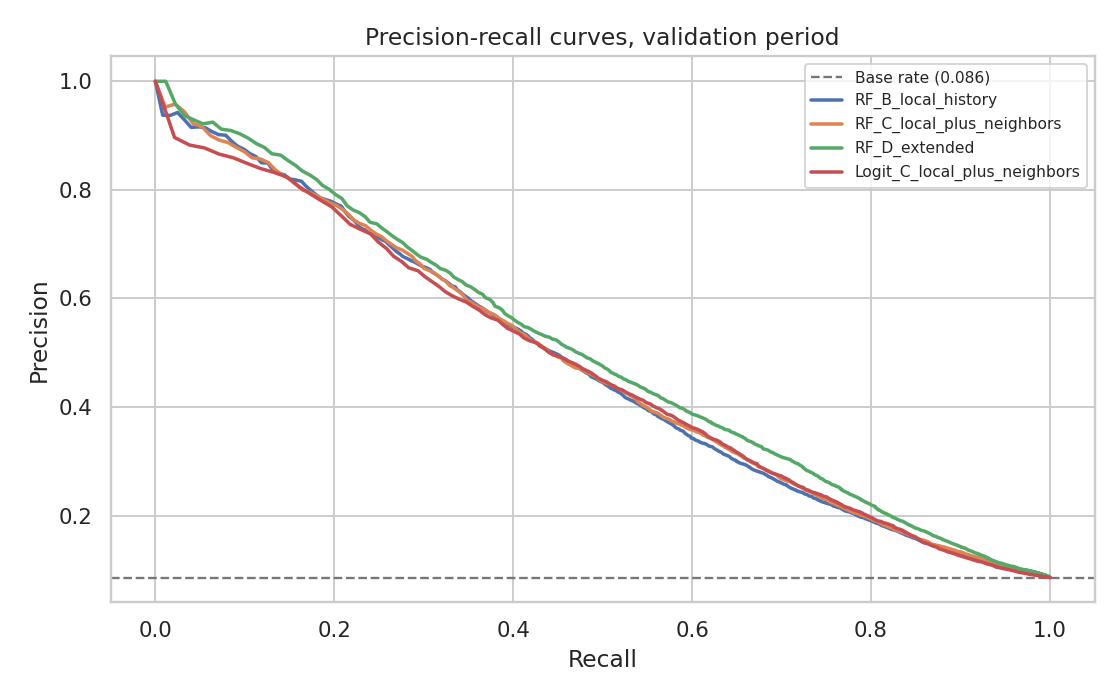

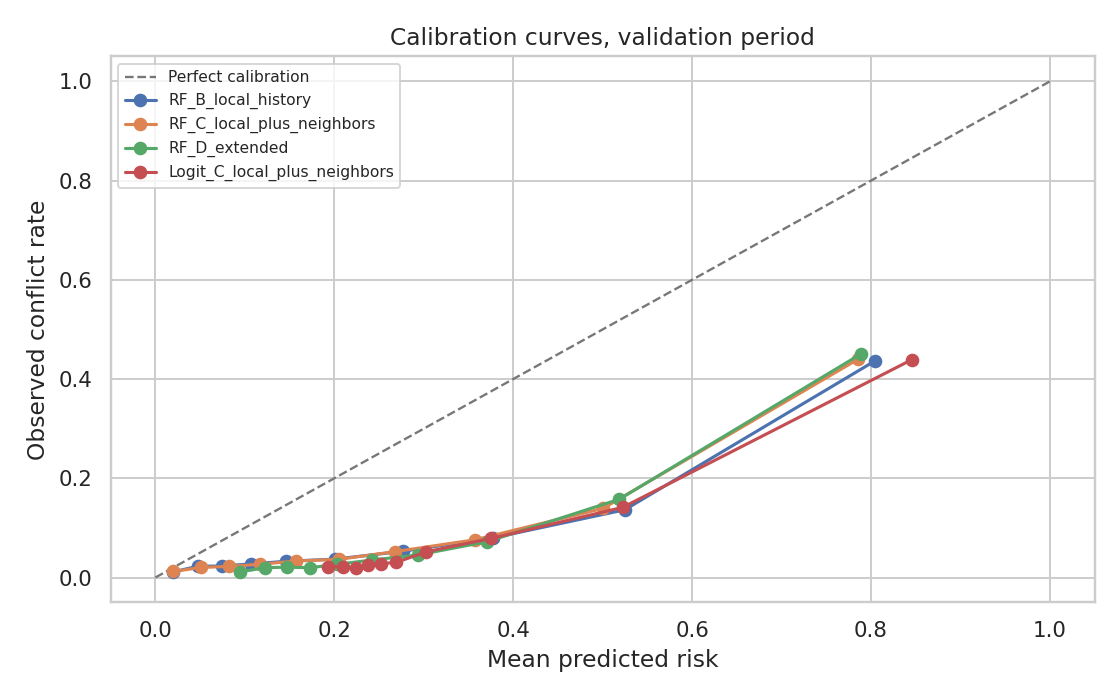

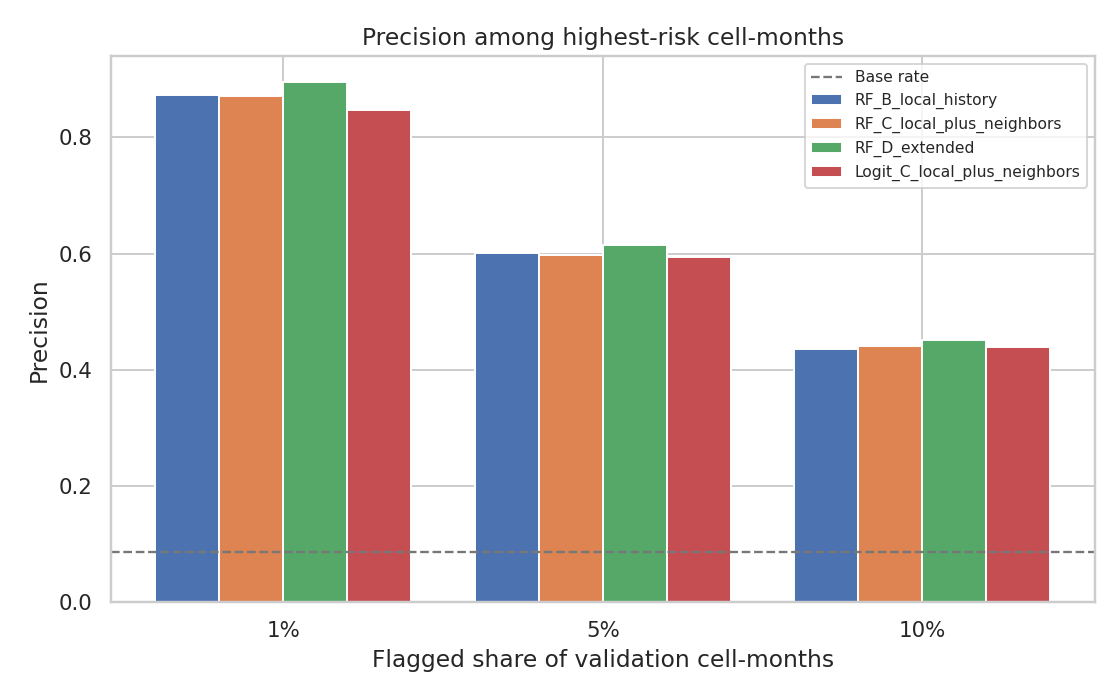

Saved fast evaluation plots and calibration table.


In [12]:
# Fast plotting helpers: keep the analytical content, but avoid plotting tens of thousands of points.
def thin_curve(x, y, max_points=600):
    x = np.asarray(x)
    y = np.asarray(y)
    if len(x) <= max_points:
        return x, y
    idx = np.unique(np.linspace(0, len(x) - 1, max_points).astype(int))
    return x[idx], y[idx]

def fast_quantile_calibration(y_true, y_prob, n_bins=10):
    d = pd.DataFrame({'y_true': np.asarray(y_true).astype(int), 'y_prob': np.asarray(y_prob)})
    d = d.sort_values('y_prob').reset_index(drop=True)
    d['bin'] = pd.qcut(d.index, q=n_bins, labels=False, duplicates='drop')
    cal = d.groupby('bin', as_index=False).agg(
        mean_predicted_risk=('y_prob', 'mean'),
        observed_conflict_rate=('y_true', 'mean'),
        n=('y_true', 'size')
    )
    return cal

base_rate = y_valid.mean()

# Precision-recall curves.
fig, ax = plt.subplots(figsize=(8, 5))
ax.axhline(base_rate, color='#777777', linestyle='--', linewidth=1.2, label=f'Base rate ({base_rate:.3f})')
for model_name, col in model_cols.items():
    precision, recall, _ = precision_recall_curve(y_valid, pred100[col])
    recall_plot, precision_plot = thin_curve(recall, precision, max_points=600)
    ax.plot(recall_plot, precision_plot, linewidth=1.8, label=model_name)
ax.set_title('Precision-recall curves, validation period')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(fontsize=8)
fig.tight_layout()
save_and_show(fig, 'precision_recall_curves_100km.png', dpi=140)

# Calibration curves.
calibration_rows = []
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot([0, 1], [0, 1], color='#777777', linestyle='--', linewidth=1.2, label='Perfect calibration')
for model_name, col in model_cols.items():
    cal = fast_quantile_calibration(y_valid, pred100[col], n_bins=10)
    cal.insert(0, 'model', model_name)
    calibration_rows.append(cal)
    ax.plot(cal['mean_predicted_risk'], cal['observed_conflict_rate'], marker='o', linewidth=1.6, label=model_name)
ax.set_title('Calibration curves, validation period')
ax.set_xlabel('Mean predicted risk')
ax.set_ylabel('Observed conflict rate')
ax.legend(fontsize=8)
fig.tight_layout()
save_and_show(fig, 'calibration_curves_100km.png', dpi=140)

calibration_table = pd.concat(calibration_rows, ignore_index=True)
calibration_table.to_csv(TABLES_DIR / '11_calibration_bins_100km.csv', index=False)

# Top-k precision plot using plain matplotlib rather than seaborn.
fig, ax = plt.subplots(figsize=(8, 5))
plot_topk = topk_eval.copy()
plot_topk['top_percent'] = (plot_topk['top_share'] * 100).astype(int).astype(str) + '%'
models = list(plot_topk['model'].unique())
top_levels = list(plot_topk['top_percent'].unique())
x = np.arange(len(top_levels))
width = 0.8 / max(1, len(models))
for j, model_name in enumerate(models):
    vals = plot_topk[plot_topk['model'] == model_name].set_index('top_percent').loc[top_levels, 'precision_at_top']
    ax.bar(x + (j - (len(models)-1)/2) * width, vals.values, width=width, label=model_name)
ax.axhline(base_rate, color='#777777', linestyle='--', linewidth=1.2, label='Base rate')
ax.set_title('Precision among highest-risk cell-months')
ax.set_xlabel('Flagged share of validation cell-months')
ax.set_ylabel('Precision')
ax.set_xticks(x)
ax.set_xticklabels(top_levels)
ax.legend(fontsize=8)
fig.tight_layout()
save_and_show(fig, 'precision_at_top_k_100km.png', dpi=140)

print('Saved fast evaluation plots and calibration table.')

## 7. Map-like sanity check

This is not a formal map, but it helps assess whether observed and predicted risk form plausible geographic clusters.

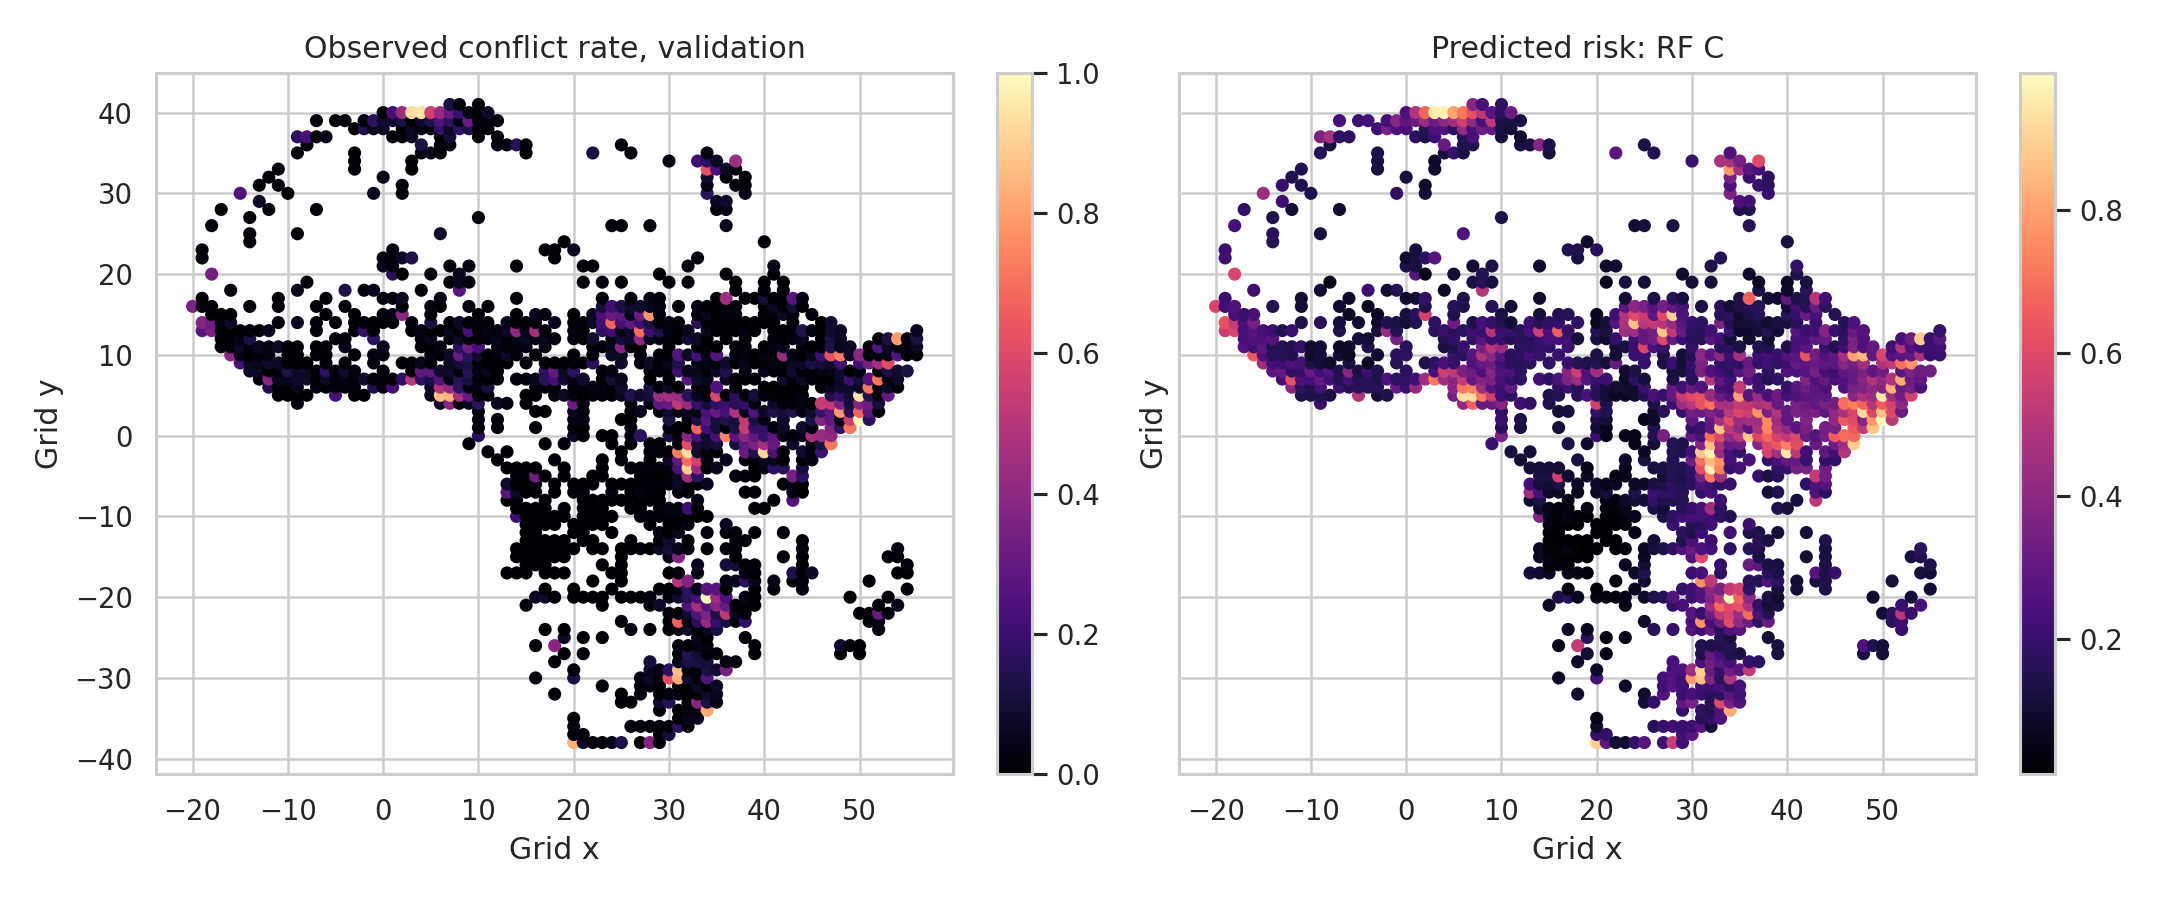

In [13]:
best_model_col = 'p_RF_C_local_plus_neighbors'
risk_map = pred100.groupby(['grid_x','grid_y']).agg(
    observed_rate=('target_conflict_next_month','mean'),
    predicted_risk=(best_model_col,'mean'),
    validation_months=('month','nunique')
).reset_index()

fig, axes = plt.subplots(1,2,figsize=(12,5),sharex=True,sharey=True)
sc1 = axes[0].scatter(risk_map['grid_x'], risk_map['grid_y'], c=risk_map['observed_rate'], s=18, cmap='magma')
axes[0].set_title('Observed conflict rate, validation')
plt.colorbar(sc1, ax=axes[0], fraction=0.046)
sc2 = axes[1].scatter(risk_map['grid_x'], risk_map['grid_y'], c=risk_map['predicted_risk'], s=18, cmap='magma')
axes[1].set_title('Predicted risk: RF C')
plt.colorbar(sc2, ax=axes[1], fraction=0.046)
for ax in axes:
    ax.set_xlabel('Grid x')
    ax.set_ylabel('Grid y')
fig.tight_layout()
save_and_show(fig, 'observed_vs_predicted_risk_map_100km.png', dpi=180)
risk_map.to_csv(PANELS_DIR / '06_validation_risk_map_100km.csv', index=False)

## 8. Robustness check: 50, 100, and 200 km

We run the same comparison between local history and local + neighboring-cell conflict for three grid sizes.

Running grid 50 km...
Running grid 100 km...
Running grid 200 km...


,model,feature_set,n_features,roc_auc,avg_precision,brier,threshold,precision,recall,f1,positive_rate_pred,grid_km,cells,cell_months,positive_share_validation
3,Logit_B_local_history,B_local_history,15,0.774477,0.352397,0.137730,0.053614,0.053614,1.000000,0.101771,1.000000,50,2702,353962,0.053614
2,Logit_C_local_plus_neighbors,C_local_plus_neighbors,18,0.791533,0.353509,0.136677,0.053614,0.053614,1.000000,0.101771,1.000000,50,2702,353962,0.053614
1,RF_B_local_history,B_local_history,15,0.789554,0.354887,0.088519,0.053614,0.067178,0.923599,0.125246,0.737112,50,2702,353962,0.053614
0,RF_C_local_plus_neighbors,C_local_plus_neighbors,18,0.795568,0.359371,0.084901,0.053614,0.066358,0.928513,0.123865,0.750185,50,2702,353962,0.053614
7,Logit_B_local_history,B_local_history,15,0.810478,0.465898,0.133163,0.086000,0.086000,1.000000,0.158380,1.000000,100,1432,187592,0.086000
6,Logit_C_local_plus_neighbors,C_local_plus_neighbors,18,0.825059,0.470489,0.132528,0.086000,0.086000,1.000000,0.158380,1.000000,100,1432,187592,0.086000
5,RF_B_local_history,B_local_history,15,0.826246,0.473382,0.108090,0.086000,0.112819,0.935453,0.201354,0.713084,100,1432,187592,0.086000
4,RF_C_local_plus_neighbors,C_local_plus_neighbors,18,0.829764,0.476184,0.103440,0.086000,0.110195,0.945087,0.197376,0.737584,100,1432,187592,0.086000
11,Logit_B_local_history,B_local_history,15,0.837426,0.616497,0.133612,0.155634,0.155799,0.999819,0.269589,0.998763,200,603,78993,0.155634
10,Logit_C_local_plus_neighbors,C_local_plus_neighbors,18,0.849420,0.623436,0.132083,0.155634,0.162309,0.990067,0.278897,0.949349,200,603,78993,0.155634


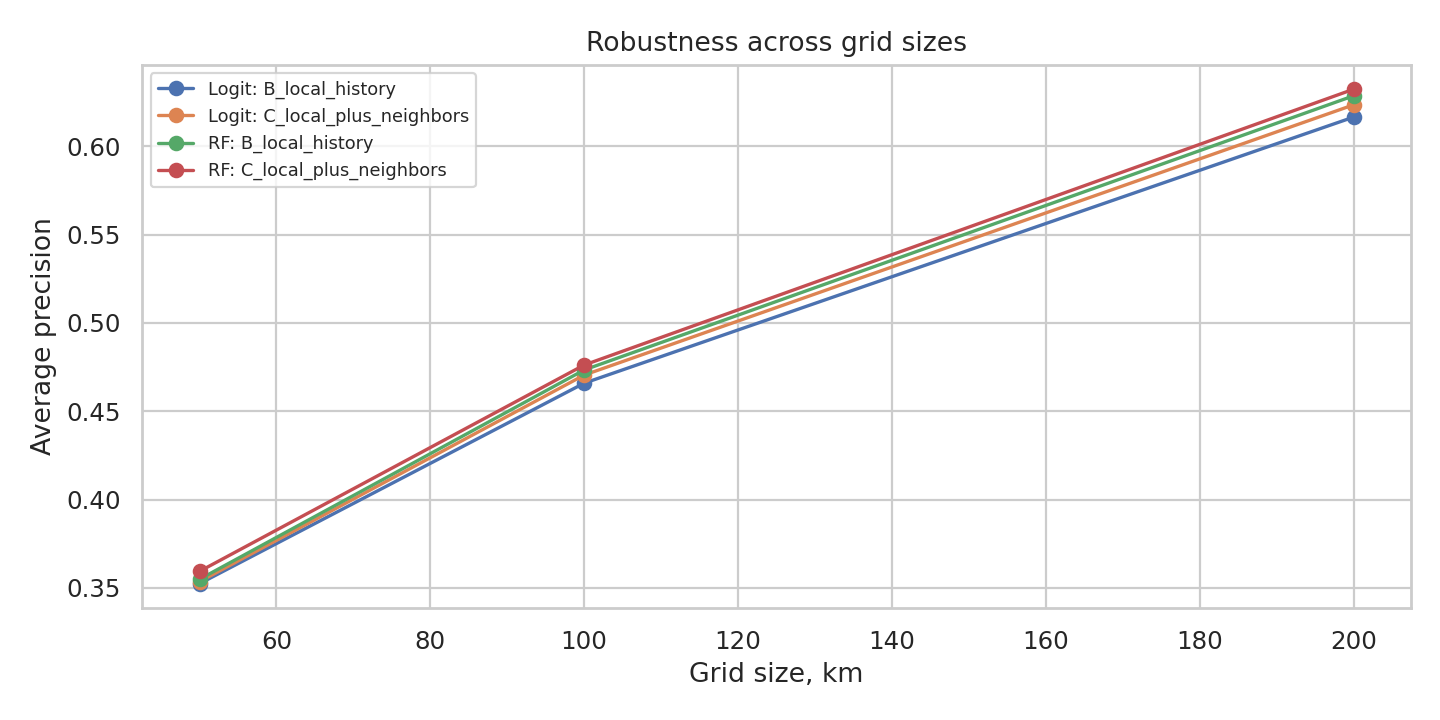

In [14]:
def run_grid_robustness(grid_sizes=(50,100,200)):
    rows = []
    for g in grid_sizes:
        print(f'Running grid {g} km...')
        p = build_panel(df, g)
        fs = {'B_local_history': LOCAL_FEATURES, 'C_local_plus_neighbors': SPATIAL_FEATURES}
        res, _ = fit_models(p, fs)
        res['grid_km'] = g
        res['cells'] = p['cell_id'].nunique()
        res['cell_months'] = len(p)
        _, valid_mask_g = make_masks(p)
        res['positive_share_validation'] = p.loc[valid_mask_g, 'target_conflict_next_month'].mean()
        rows.append(res)
    return pd.concat(rows, ignore_index=True)

robustness_results = run_grid_robustness(ROBUSTNESS_GRID_KM)
display(robustness_results.sort_values(['grid_km','model']))
robustness_results.to_csv(TABLES_DIR / '07_robustness_50_100_200km.csv', index=False)

fig, ax = plt.subplots(figsize=(9,4.5))
tmp = robustness_results.copy()
tmp['family'] = tmp['model'].str.extract(r'^(Logit|RF)_')
tmp['feature_label'] = tmp['feature_set']
for (fam, label), sub in tmp.groupby(['family','feature_label']):
    sub = sub.sort_values('grid_km')
    ax.plot(sub['grid_km'], sub['avg_precision'], marker='o', label=f'{fam}: {label}')
ax.set_title('Robustness across grid sizes')
ax.set_xlabel('Grid size, km')
ax.set_ylabel('Average precision')
ax.legend(fontsize=8)
fig.tight_layout()
save_and_show(fig, 'robustness_grid_sizes.png', dpi=160)